# Credit Card Fraud Detection Using Machine Learning

# Project Overview

This project focuses on building a machine learning model to detect fraudulent credit card transactions. Fraud detection is a critical problem in the financial industry due to the significant financial losses associated with fraudulent activities.

The dataset used in this project contains real-world anonymized transaction data, where the goal is to classify transactions as either legitimate or fraudulent. Due to the highly imbalanced nature of the dataset, special techniques are applied to improve model performance.

This project demonstrates an end-to-end machine learning pipeline, including data preprocessing, exploratory data analysis, feature scaling, model training, handling class imbalance, and evaluation using appropriate metrics.


# Project Goals

* Build a machine learning model to accurately detect fraudulent transactions
* Handle imbalanced data effectively
* Compare different classification models
* Evaluate models using precision, recall, and F1-score instead of just accuracy
* Create a reusable machine learning pipeline


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Preview first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Explore the Data

In [5]:
df.info()

df["Class"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64

# Visualize Class Imbalance

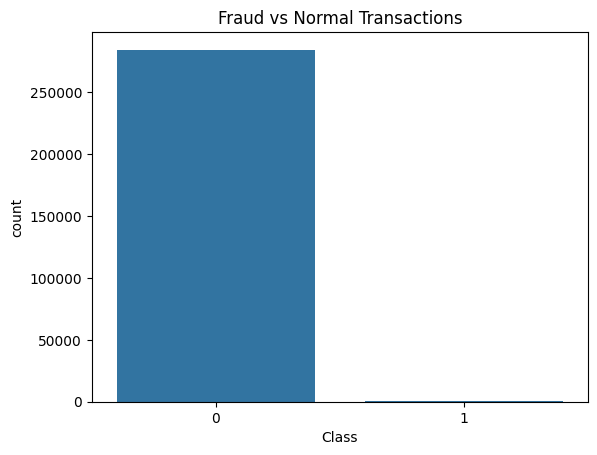

In [6]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

The count plot shows a severe class imbalance where normal transactions vastly outnumber fraudulent ones. Fraud cases represent less than 1% of the dataset, which makes them difficult to visualize on the same scale.

# Log Scale Plot

Better Ways to Visualize the difference 

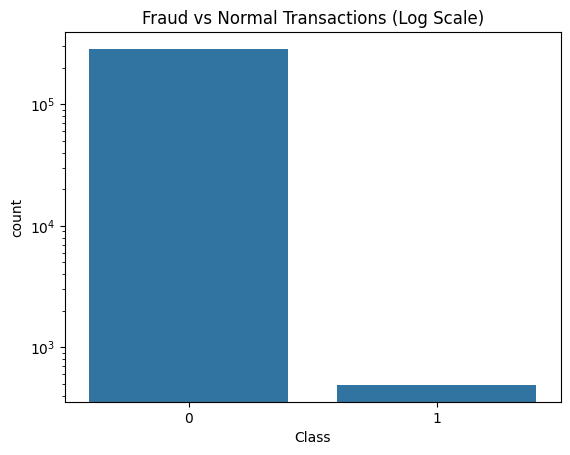

In [20]:
sns.countplot(x="Class", data=df)
plt.yscale("log")  
plt.title("Fraud vs Normal Transactions (Log Scale)")
plt.show()

# Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale 'Amount' column
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Split Data

In [8]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Stratify ensures same fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Train Logistic Regression Model

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Evaluation
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.55      0.68        98

    accuracy                           1.00     56962
   macro avg       0.95      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



/Users/macbookprom116gb/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model achieved good precision of 90%, meaning most predicted fraud cases were correct. However, its recall was only 55%, indicating that nearly half of the fraudulent transactions were missed.
In fraud detection, missing fraudulent transactions is critical, so this model is not suitable despite its simplicity.

# Train Random Forest Model

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.74      0.83        98

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



The Random Forest model achieved very high precision of 94% for fraud detection, meaning most flagged transactions were actually fraudulent. However, the recall was around 74%, indicating that some fraudulent transactions were still missed.
Compared to my previous model, Random Forest slightly improved precision but reduced recall. Since fraud detection prioritizes minimizing missed fraud cases, improving recall would be an important next step.

# Handle Imbalanced Data

In [18]:
from sklearn.utils import resample

# Combining features and target
train_data = pd.concat([X_train, y_train], axis=1)

# Separating classes
fraud = train_data[train_data.Class == 1]
normal = train_data[train_data.Class == 0]

# Upsample fraud class
fraud_upsampled = resample(
    fraud,
    replace=True,
    n_samples=len(normal),
    random_state=42
)

# Combining balanced dataset
balanced_data = pd.concat([normal, fraud_upsampled])

# Spliting again
X_train_bal = balanced_data.drop("Class", axis=1)
y_train_bal = balanced_data["Class"]

# Train Model on Balanced Data

In [14]:
rf.fit(X_train_bal, y_train_bal)

balanced_preds = rf.predict(X_test)

print(classification_report(y_test, balanced_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.76      0.83        98

    accuracy                           1.00     56962
   macro avg       0.96      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



The model performs extremely well on normal transactions, with near-perfect precision and recall. For fraudulent transactions, it achieves a precision of 93%, meaning most flagged transactions are truly fraudulent. However, the recall is around 76%, indicating that about 24% of fraud cases are still missed.
In fraud detection, recall is particularly important, so improving it would be a key next step, even if it slightly increases false positives.

# Building ML Pipeline

In [15]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier())])

# Confusion Matrix

A table that shows how your model is performing in terms of:

* True Positives (correct fraud detection)
* False Positives (false alarms)
* False Negatives
* 
  Missing fraud (False Negative) is worse than flagging a normal transaction.

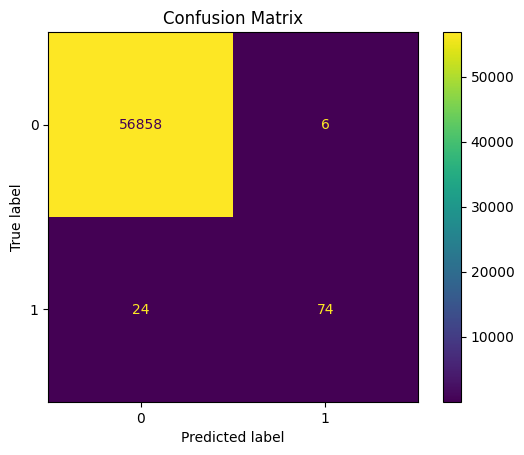

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, balanced_preds)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model performs very well on normal transactions, with a high number of true negatives. More importantly, it detects most fraud cases with a recall of around 75%.
However, there are still some false negatives, meaning some fraudulent transactions were missed, which is a critical issue in fraud detection.
The model also has very few false positives, indicating high precision and low false alarm rate.

# ROC Curve

ROC Curve Shows model performance across thresholds. AUC shows Single score summarizing performance. Accuracy is misleading in imbalanced data
ROC shows true performance. I used ROC-AUC to evaluate model performance because it’s robust for imbalanced datasets.

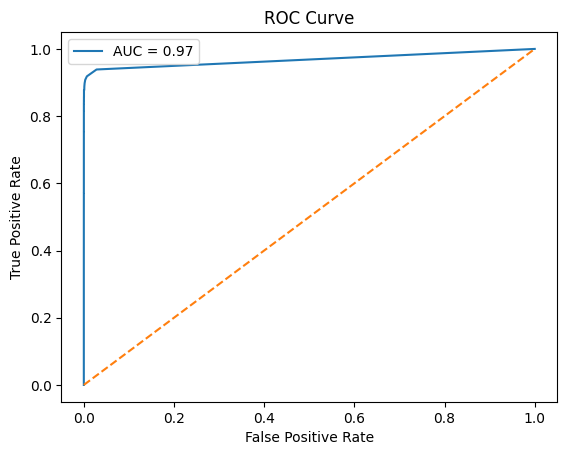

In [17]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_probs = rf.predict_proba(X_test)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC-AUC score of 0.97 indicates that the model has excellent discriminative ability. It means that in 97% of cases, the model ranks a randomly chosen fraudulent transaction higher than a normal one. This shows the model performs well across different classification thresholds, which is especially important for imbalanced datasets.

## Conclusion

In this project, I developed a machine learning model to detect fraudulent credit card transactions using a highly imbalanced real-world dataset. The analysis demonstrated that traditional metrics like accuracy are not sufficient for evaluating model performance in such scenarios.

Logistic Regression served as a useful baseline model but showed poor performance in detecting fraud due to low recall. In contrast, the Random Forest model significantly improved performance, achieving high precision and a better balance between precision and recall.

The confusion matrix and ROC-AUC score (0.97) confirmed that the model has strong discriminative ability. However, the results also highlighted that some fraudulent transactions were still missed, indicating room for improvement.

Overall, this project emphasizes the importance of selecting appropriate evaluation metrics, understanding class imbalance, and choosing models that align with the business objective of minimizing financial loss due to undetected fraud.


## Next Steps

* Improve recall by adjusting the classification threshold to reduce missed fraud cases
* Perform hyperparameter tuning (e.g., GridSearchCV) to optimize model performance
* Experiment with additional models to further improve detection capability
* Incorporate cross-validation for more robust model evaluation
* Deploy the model as a web application using tools like Streamlit
* Explore real-time fraud detection systems for practical implementation
